In [1]:
import pandas as pd

In [2]:
CSV_PATH = "../data/draws_clean.csv"

# Replace the column names 
column_names = [
    "draw_number", "draw_date",
    "main_1", "main_2", "main_3", "main_4", "main_5" ,"main_6",
    "bonus", "powerball"
]

# header=0 means the original header row
# names=column_names means throw away those original header names and use mine instead
df = pd.read_csv(CSV_PATH, header=0, names=column_names)

# Shape gives us the number of rows and columns
print(df.shape)

# Head gives us the first 5 rows
df.head()

(1520, 10)


,draw_number,draw_date,main_1,main_2,main_3,main_4,main_5,main_6,bonus,powerball
0,2593,2026-06-10,2,7,12,17,21,37,35,6
1,2592,2026-06-06,3,22,29,37,39,40,13,1
2,2591,2026-06-03,1,4,9,11,13,36,24,9
3,2590,2026-05-30,8,10,29,35,36,39,3,3
4,2589,2026-05-27,6,17,19,21,27,32,28,10


In [3]:





df["draw_date"] = pd.to_datetime(df["draw_date"])

df = df.sort_values("draw_date").reset_index(drop=True)

print(df["draw_date"].dtype)
print("Oldest:", df["draw_date"].min())
print("Newest:", df["draw_date"].max())
df.head()

datetime64[us]
Oldest: 2008-01-05 00:00:00
Newest: 2026-06-10 00:00:00


,draw_number,draw_date,main_1,main_2,main_3,main_4,main_5,main_6,bonus,powerball
0,1074,2008-01-05,3,8,14,18,21,36,35,3
1,1075,2008-01-12,5,14,16,19,22,40,33,9
2,1076,2008-01-19,8,10,12,26,36,38,21,5
3,1077,2008-01-26,10,15,19,22,34,40,17,4
4,1078,2008-02-02,2,4,12,22,32,38,20,8


In [4]:
# Faltten all main number columns into the 1D array for counting easier

main_cols = ["main_1", "main_2", "main_3", "main_4", "main_5", "main_6", "bonus"]

# df[main_cols] passing a list of column from the df[main_cols]. 1520 rows and 7 column table.
# .values is that convers the pandas table into a numpy array (raw data).
# .flatten() reshapes the data from 2D to 1D.
all_main_numbers = df[main_cols].values.flatten()

# len() counts the number of elements in the array.
print(f"Total number draws to counts: {len(all_main_numbers)}")

Total number draws to counts: 10640


1     275
2     271
3     254
4     250
5     264
6     259
7     261
8     231
9     255
10    294
11    264
12    278
13    289
14    243
15    289
16    257
17    293
18    265
19    296
20    258
21    270
22    279
23    290
24    275
25    278
26    257
27    250
28    263
29    262
30    261
31    271
32    271
33    253
34    257
35    270
36    248
37    262
38    259
39    236
40    282
Name: count, dtype: int64


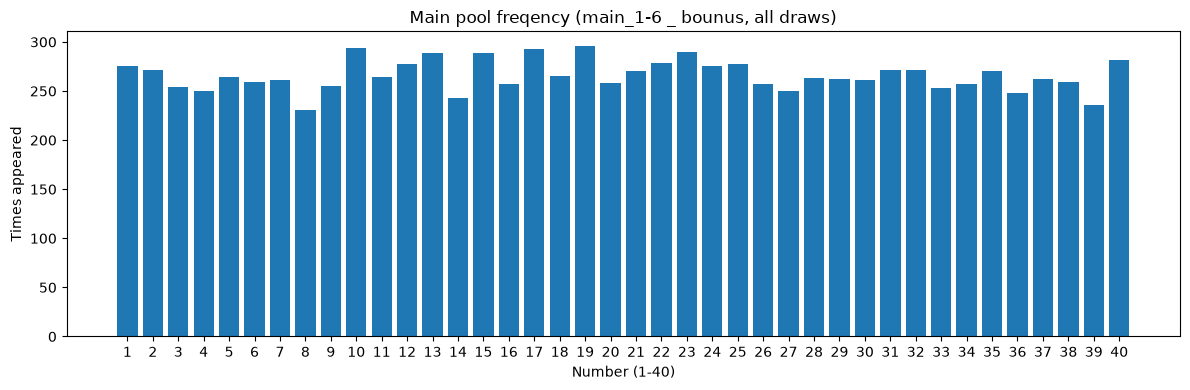

'\nprint("Top 3 most frequent:")\nreorder by count, highest first\nprint(freq.sort_values(ascending=False).head(3))\n\nprint("Bottom 3 least frequent:")\nreorder by count, lowest first\nprint(freq.sort_values(ascending=True).head(3))\n\n'

In [5]:
# Takes all_main_numbers from cell4 and counts how many times each number(1-40) apperaed.

import pandas as pd
import matplotlib.pyplot as plt

# pd.Series(all_main_numbers) is wraps it back into a pandas Series(single-column table.)
# .value_counts() counts the number of occurences of each number.
# .sort_index() sorts the numbers by their index.(easier to read.)
freq = pd.Series(all_main_numbers).value_counts().sort_index()

print(freq)

plt.figure(figsize=(12, 4))
plt.bar(freq.index, freq.values)
plt.xlabel("Number (1-40)")
plt.ylabel("Times appeared")
plt.title("Main pool freqency (main_1-6 _ bounus, all draws)")
plt.xticks(range(1, 41)) # Show every number 1-40 on the x-axis
plt.tight_layout() # Make sure the plot is not cut off
plt.show()
# Practice 
'''
print("Top 3 most frequent:")
reorder by count, highest first
print(freq.sort_values(ascending=False).head(3))

print("Bottom 3 least frequent:")
reorder by count, lowest first
print(freq.sort_values(ascending=True).head(3))

'''

powerball
1     162
2     172
3     152
4     138
5     165
6     150
7     139
8     157
9     136
10    149
Name: count, dtype: int64


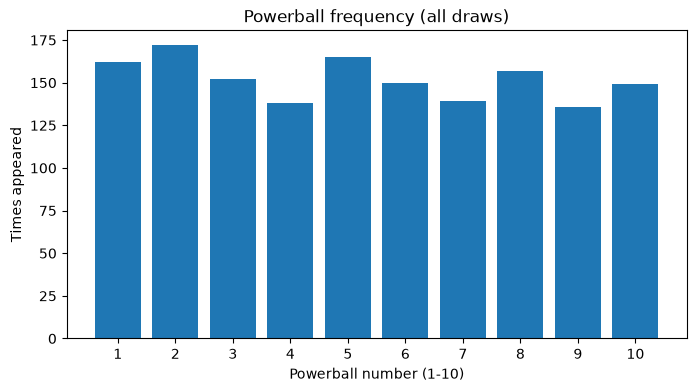

In [6]:
# Powerball frequency

pb_freq = df["powerball"].value_counts().sort_index()

print(pb_freq)

plt.figure(figsize=(8, 4))
plt.bar(pb_freq.index, pb_freq.values)
plt.xlabel("Powerball number (1-10)")
plt.ylabel("Times appeared")
plt.title("Powerball frequency (all draws)")
plt.xticks(range(1, 11))
plt.show()

In [7]:
# Slice the last 52 draws (6 months)

RECENT_DRAWS = 52

recent_df = df.tail(RECENT_DRAWS)

print(f"recent window: {recent_df['draw_date'].min().date()} to {recent_df['draw_date'].max().date()}")
print(f"Number of draws: {len(recent_df)}")


recent window: 2025-12-13 to 2026-06-10
Number of draws: 52


In [8]:
# Recent frequency

# .values makes it a numpy array.
# .flatten() makes it a 1D array.
recent_main = recent_df[main_cols].values.flatten()
# pd.Series(recent_main) makes it a pandas Series.
# .value_counts() counts the number of occurences of each number.
# .sort_index() sorts the numbers by their index.(easier to read.)
recent_freq = pd.Series(recent_main).value_counts().sort_index()

print("top 3 recent main numbers:")
# ascending=False means order from highest to lowest.
print(recent_freq.sort_values(ascending=False).head(3))

# Compare recent and all-time frequency
compare = pd.DataFrame({ # Buils a table from two Series (columns all_time and recent).
    "all_time": freq,
    "recent": recent_freq
}).fillna(0) # If there is no value, fill it with 0.

# Calculate the difference between recent and all-time frequency.
compare["all_time_rate"] = compare["all_time"] / len(df)
compare["recent_rate"] = compare["recent"] / len(recent_df)
compare["difference"] = compare["recent_rate"] - compare["all_time_rate"]

print("Hotter recently:")
print(compare.sort_values("difference", ascending=False).head(5))
print("Colder recently:")
print(compare.sort_values("difference", ascending=True).head(5))

print(compare.loc[[14,26]])

top 3 recent main numbers:
24    14
14    14
22    12
Name: count, dtype: int64
Hotter recently:
    all_time  recent  all_time_rate  recent_rate  difference
14       243      14       0.159868     0.269231    0.109362
24       275      14       0.180921     0.269231    0.088310
22       279      12       0.183553     0.230769    0.047217
9        255      11       0.167763     0.211538    0.043775
34       257      11       0.169079     0.211538    0.042460
Colder recently:
    all_time  recent  all_time_rate  recent_rate  difference
20       258       5       0.169737     0.096154   -0.073583
37       262       6       0.172368     0.115385   -0.056984
30       261       6       0.171711     0.115385   -0.056326
15       289       7       0.190132     0.134615   -0.055516
25       278       7       0.182895     0.134615   -0.048279
    all_time  recent  all_time_rate  recent_rate  difference
14       243      14       0.159868     0.269231    0.109362
26       257      10       0.169

In [9]:
# Recent powerball frequency

recent_pb_freq = recent_df["powerball"].value_counts().sort_index()

print("Top 3 recent powerball numbers:")
print(recent_pb_freq.sort_values(ascending=False).head(3))

pb_compare = pd.DataFrame({
    "all_time": pb_freq,
    "recent": recent_pb_freq
}).fillna(0)

pb_compare["all_time_rate"] = pb_compare["all_time"] / len(df)
pb_compare["recent_rate"] = pb_compare["recent"] / len(recent_df)
pb_compare["difference"] = pb_compare["recent_rate"] - pb_compare["all_time_rate"]

print("Hotter recently:")
print(pb_compare.sort_values("difference", ascending=False).head(3))

print("Colder recently:")
print(pb_compare.sort_values("difference", ascending=True).head(3))

Top 3 recent powerball numbers:
powerball
1    9
3    9
6    8
Name: count, dtype: int64
Hotter recently:
           all_time  recent  all_time_rate  recent_rate  difference
powerball                                                          
3               152       9       0.100000     0.173077    0.073077
1               162       9       0.106579     0.173077    0.066498
6               150       8       0.098684     0.153846    0.055162
Colder recently:
           all_time  recent  all_time_rate  recent_rate  difference
powerball                                                          
2               172       1       0.113158     0.019231   -0.093927
8               157       2       0.103289     0.038462   -0.064828
7               139       2       0.091447     0.038462   -0.052986


In [10]:
# Gap for main numbers and Powerball.

def last_seen_gap(number, dataframe, columns):
    """
    How many draws since 'number' last appeared in any of 'columns'?
    0 = appeared in the most recent draw
    """

    # Check the numbers(1-40), if they was shown in past draws. 
    # Then, return the loction of the column.
    for i in range(len(dataframe) -1, -1, -1):
        row = dataframe.iloc[i][columns]
        if number in row.values:
            return (len(dataframe) - 1) - i
    return len(dataframe)

# Save the numbers of the gap in dictionary with dictionary comprehension
gaps = {n: last_seen_gap(n, df, main_cols) for n in range(1, 41)}
gap_series = pd.Series(gaps).sort_index()

# Save the powerball of the gap in dictionary with dictionary comprehension
pb_gaps = {n: last_seen_gap(n, df, ["powerball"]) for n in range(1, 11)}
pb_gap_series = pd.Series(pb_gaps).sort_index()

print("Largest gaps (longest since last seen):")
print(gap_series.sort_values(ascending=False).head(5))

print("Smallest gaps (seen most recently):")
print(gap_series.sort_values(ascending=True).head(5))

print("Largest Powerball gaps (longest since last seen):")
print(pb_gap_series.sort_values(ascending=False).head(5))

print("Smallest Powerball gaps (seen most recently):")
print(pb_gap_series.sort_values(ascending=True).head(5))




Largest gaps (longest since last seen):
31    12
33    12
30    11
15    11
25    11
dtype: int64
Smallest gaps (seen most recently):
2     0
7     0
12    0
17    0
21    0
dtype: int64
Largest Powerball gaps (longest since last seen):
8    35
7    30
4    17
2    13
5     7
dtype: int64
Smallest Powerball gaps (seen most recently):
6     0
1     1
9     2
3     3
10    4
dtype: int64


In [11]:
# Normalize one signal (conceptual)

def min_max_scale(series):
    """
    Scale values to 0.0 - 1.0. Same min and max -> all 0.5.
    Use min-max scaling ((series - lo) / (hi - lo)).
    """
    lo = series.min()
    hi = series.max()
    # If the hi == lo, which means it has middle score (0.5).
    return series * 0 + 0.5 if hi == lo else (series - lo) / (hi - lo)


# Normalize raw all-time counts.
freq_score = min_max_scale(freq)

# Normalize recent frequency.
recency_score = min_max_scale(compare["recent_rate"])

# Normalize gap score.
gap_score = min_max_scale(gap_series)

print(freq_score.head())
print(recency_score.head())
print(gap_score.head())



1    0.676923
2    0.615385
3    0.353846
4    0.292308
5    0.507692
Name: count, dtype: float64
1    0.444444
2    0.666667
3    0.555556
4    0.333333
5    0.444444
Name: recent_rate, dtype: float64
1    0.166667
2    0.000000
3    0.083333
4    0.166667
5    0.416667
dtype: float64


In [12]:
# Combine scores with weights.
# Weight will be changed to see which one is the best.
# 0.4, 0.35, 0.25 is the educated starting point.
WEIGHT_FREQ = 0.4
WEIGHT_RECENCY = 0.35
WEIGHT_GAP = 0.25

# Normalize powerball frequency.
pb_freq_score = min_max_scale(pb_freq)
pb_recency_score = min_max_scale(pb_compare["recent_rate"])
pb_gap_score = min_max_scale(pb_gap_series)

# Combine scores with weights.
main_score = (
    WEIGHT_FREQ * freq_score 
    + WEIGHT_RECENCY * recency_score
    + WEIGHT_GAP * gap_score
)

powerball_score = (
    WEIGHT_FREQ * pb_freq_score
    + WEIGHT_RECENCY * pb_recency_score
    + WEIGHT_GAP * pb_gap_score
)

print("Top 10 main numbers by combined score:")
print(main_score.sort_values(ascending=False).head(10))

print("Bottom 5 main numbers:")
print(main_score.sort_values(ascending=True).head(5))

print("Top 5 powerball by combined score:")
print(powerball_score.sort_values(ascending=False).head(5))



Top 10 main numbers by combined score:
15    0.663868
24    0.662436
10    0.644637
23    0.643632
31    0.612821
19    0.600000
25    0.596175
22    0.588440
17    0.575983
13    0.572201
dtype: float64
Bottom 5 main numbers:
39    0.168269
8     0.218056
37    0.229658
4     0.275256
27    0.278034
dtype: float64
Top 5 powerball by combined score:
powerball
1    0.646032
3    0.549206
5    0.547222
8    0.527083
2    0.492857
dtype: float64


In [ ]:
# Pick one valid line (6 mains + 1 powerball)
# 1. Defines filter rules. (odd/even, consecutive).
# 2. Pick 6 main numbers that score high and pass filters.
# 3. Pick powerball.
"""
Top 18 by score
      ↓
All 6-number combos from those 18
      ↓
Skip if odd/even or 4+ consecutive fails
      ↓
Among valid ones, pick highest sum of scores
      ↓
Add best powerball → print one line
"""
# Build every possible 6 number set from a list.
from itertools import combinations

# Filter funtions.
# Count the number of odd numbers.
def count_odd(numbers):
    return sum(1 for n in numbers if n % 2 == 1)

# False if the number of odd numbers is 0 or 6.
# Allow mixs like 3 odd + 3 even,4+2,5+1, etc.
def valid_odd_even(numbers):
    odd = count_odd(numbers)
    return odd not in (0, 6)

# False if the max number of consecutive numbers is 4.
def max_consecutive_run(numbers):
    sorted_num = sorted(numbers)
    max_run = 1
    current_run = 1
    for i in range(1, len(sorted_num)):
        if sorted_num[i] == sorted_num[i-1] + 1:
            current_run += 1
            max_run = max(max_run, current_run)
        
        else:
            current_run = 1
    return max_run

# True only if longest run is 3 or less
def valid_consecutive_run(numbers):
    return max_consecutive_run(numbers) < 4

# Both checks must pass
def passes_filters(numbers):
    return valid_odd_even(numbers) and valid_consecutive_run(numbers)


CANDIDATE_POOL_SIZE = 18    

# Take 18 numbers from the main_score.
candidates = main_score.sort_values(ascending=False).head(CANDIDATE_POOL_SIZE).index.tolist()

#  Not winning yet.
best_line = None
# Starting "best so far"
best_line_score = 1

# Try every possible combination of 6 numbers from the candidates.
for combo in combinations(candidates, 6):
    mains = sorted(combo)
    if not passes_filters(mains):
        continue
    total  = main_score.loc[list(combo)].sum()
    if total > best_line_score:
        best_line_score = total
        best_line = mains

print("Best valid main line:", best_line)
print("Combines score:", best_line_score)

best_pb = powerball_score.sort_values(ascending=False).idxmax()

print(f"\nSuggested line:")
print("Main:", " ".join(f"{n:02d}" for n in best_line), "+ PB", f"{best_pb}")


Best valid main line: [10, 15, 19, 23, 24, 31]
Combines score: 3.8273931623931627

Suggested line:
Main: 10 15 19 23 24 31 + PB 1
